<a href="https://colab.research.google.com/github/Sohan82-star/machine-learning-projects/blob/main/California_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Housing Project **

In [ ]:
from pathlib import Path

import pandas as pd

import tarfile

import urllib.request

def load_housing_data():
  tarball_path = Path("datasets/housing.tgz")
  if not tarball_path.is_file():
    Path("datasets").mkdir(parents = True , exist_ok = True )
    url = "https://github.com/ageron/data/raw/main/housing.tgz"
    urllib.request.urlretrieve(url , tarball_path)
  with tarfile.open(tarball_path) as housing_tarball:
      housing_tarball.extractall(path="datasets")
  return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

housing.head()


/tmp/ipykernel_6367/905518090.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
housing['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


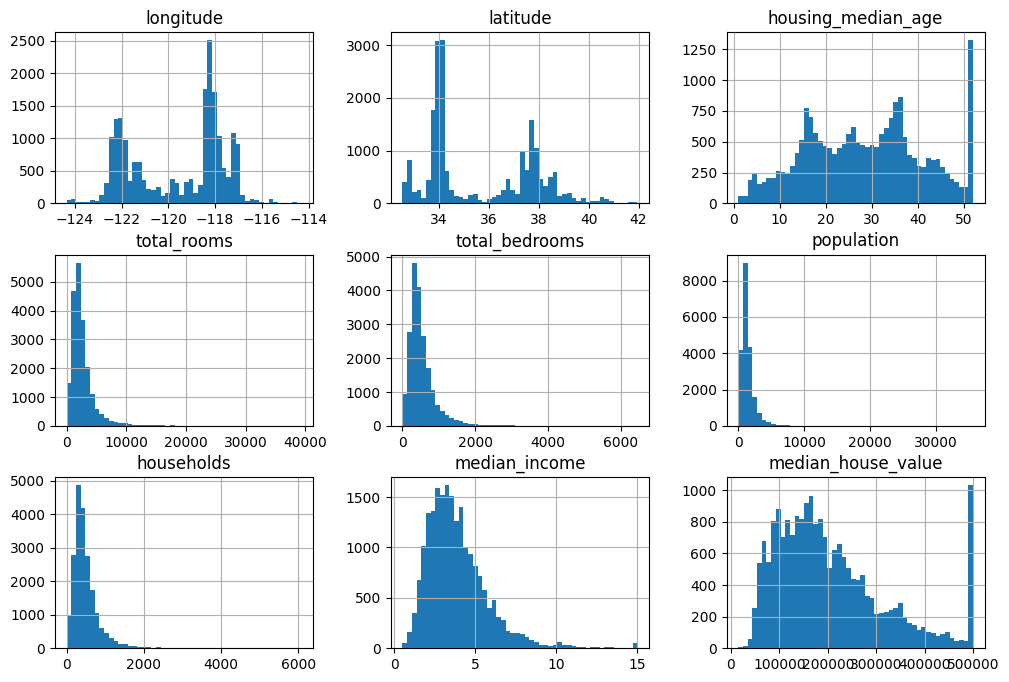

In [ ]:
import matplotlib.pyplot as plt

housing.hist(bins = 50 , figsize = (12,8))
plt.show()

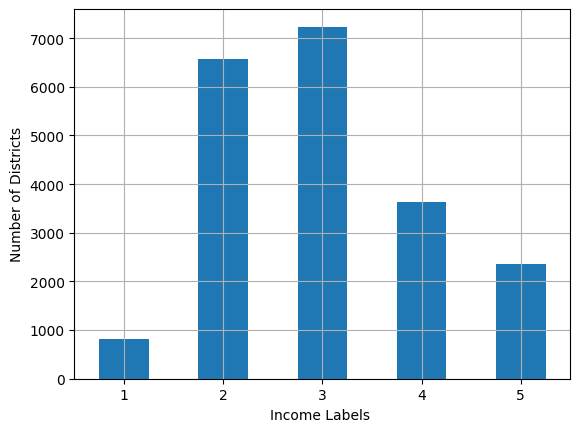

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

train_set,test_set = train_test_split(housing , random_state = 42 , test_size = 0.2 )

housing['income_cat'] = pd.cut(housing['median_income'],bins = [0. , 1.5 , 3.0 , 4.5 , 6. , np.inf],labels=[1 , 2, 3, 4, 5])

housing['income_cat'].value_counts().sort_index().plot.bar(rot = 0,grid = True )

plt.xlabel("Income Labels ")
plt.ylabel("Number of Districts")
plt.show()


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

strat_train , strat_test = train_test_split(housing ,  stratify = housing['income_cat'] , test_size = 0.2 , random_state = 42 )

strat_test['income_cat'].value_counts().sort_index() / len(strat_test)


,count
income_cat,
1,0.039971
2,0.318798
3,0.350533
4,0.176357
5,0.114341


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

strat_train['income_cat'].value_counts().sort_index() / len(strat_train)

,count
income_cat,
1,0.039789
2,0.318859
3,0.350594
4,0.176296
5,0.114462


In [ ]:
for i in (strat_train , strat_test):
  i.drop(['income_cat'] , axis = 1 , inplace=True )

In [ ]:
housing = strat_train.copy()

# Exploring And Data Visualizing

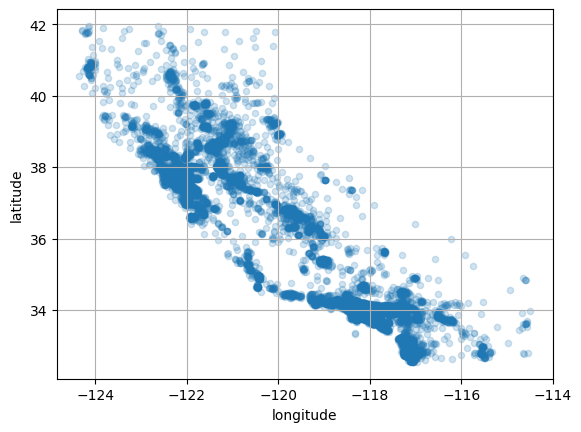

In [ ]:
housing.plot(kind = "scatter" , x="longitude" , y='latitude' , grid = True , alpha = 0.2)

plt.show()

<Axes: xlabel='longitude', ylabel='latitude'>

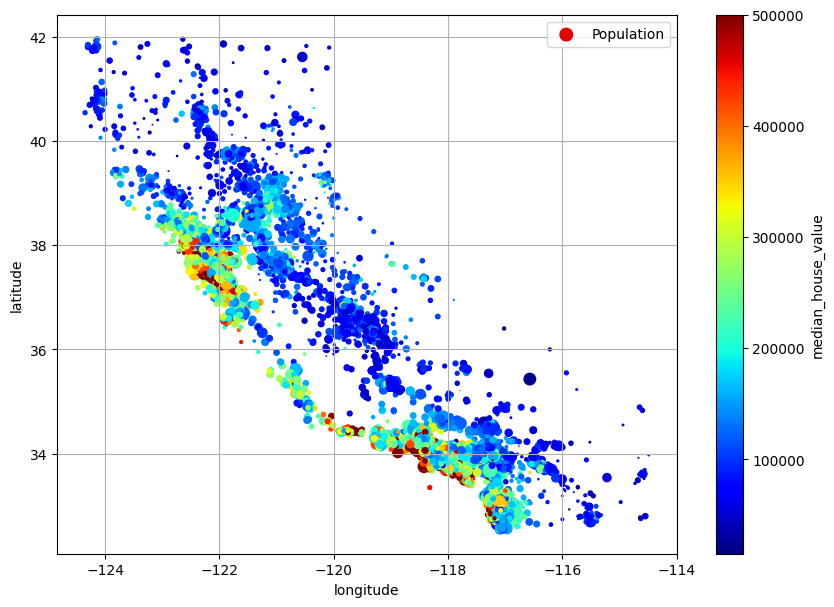

In [ ]:
housing.plot(kind='scatter' , x ='longitude', y = 'latitude' , grid=True , s= housing['population']/100 , c='median_house_value' , cmap='jet' , colorbar = True , sharex = False , label='Population' ,legend = True , figsize = (10,7))

In [ ]:
corr_matrix = housing.corr(numeric_only = True)

In [ ]:
corr_matrix['median_house_value'].sort_values(ascending=False )

,median_house_value
median_house_value,1.000000
median_income,0.688380
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
longitude,-0.050859
latitude,-0.139584


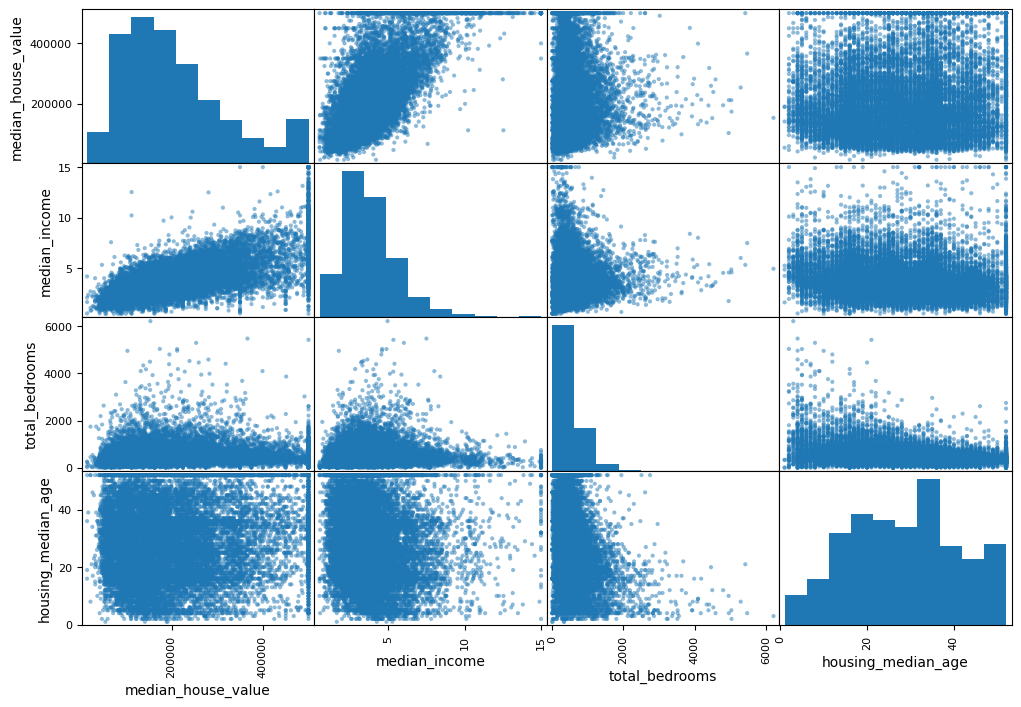

In [ ]:
# Visualing Correlation with respect to Median House values , Using Scatter Plt

from pandas.plotting import scatter_matrix

attributes = ['median_house_value' , 'median_income' ,'total_bedrooms' , 'housing_median_age']

scatter_matrix(housing[attributes] , figsize=(12,8))

plt.show()

<Axes: xlabel='median_income', ylabel='median_house_value'>

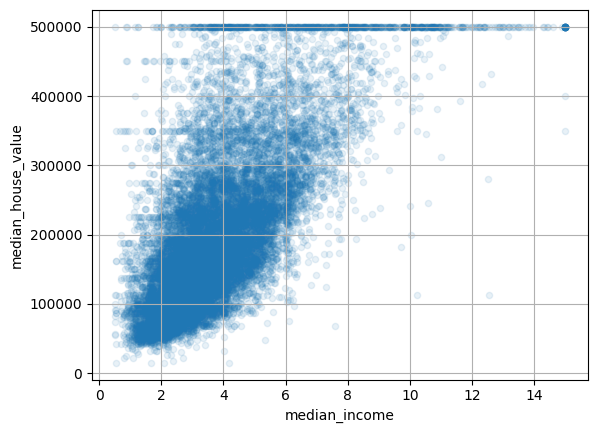

In [ ]:
housing.plot(kind="scatter" , x = "median_income" , y='median_house_value' , alpha = 0.1 , grid = True)

In [ ]:
# Attribute Combination

housing['room_per_house'] = housing['total_rooms'] / housing["households"]
housing['bedroom_ratio']  = housing['total_bedrooms'] / housing['total_rooms']
housing['people_per_house'] = housing['population'] / housing['households']

In [ ]:
corrr_matrix = housing.corr(numeric_only = True)

corrr_matrix['median_house_value'].sort_values(ascending = False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
room_per_house,0.143663
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
people_per_house,-0.038224
longitude,-0.050859


In [ ]:
housing = strat_train.drop("median_house_value" , axis = 1 )

housing_labels = strat_train['median_house_value'].copy()

In [ ]:
#housing.dropna(subset=['total_bedrooms'] , inplace = True )

In [ ]:
#housing.drop("total_bedrooms"  , axis = 1 )



In [ ]:
#median = housing['total_bedrooms'].median()
#housing['total_bedrooms'].fillna(median , inplace= True)


In [ ]:
from sklearn.impute import SimpleImputer

impute = SimpleImputer(strategy = "median" )

In [ ]:
# Since Median is an mathematical Computation tool , it works only for numerical data . Our dataset contains categorical
# attribute "Ocean proximity " that should be excluded

housing_num = housing.select_dtypes(include = [np.number])

# fitting the numerical attributes in to the imputer instance or object created above

impute.fit(housing_num)

SimpleImputer(strategy='median')

In [ ]:
housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [ ]:
X = impute.transform(housing_num)

In [ ]:
impute.strategy

'median'

In [ ]:
impute.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [ ]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

In [ ]:
housing_cat = housing[["ocean_proximity"]]

housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


In [ ]:
# Converting Categorical attributes to Numbers . Using OrdinalEncoder

from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()

housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)


housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [ ]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

encoded_data = encoder.fit_transform(housing_cat)

In [ ]:
encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1,1))

housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [ ]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

housing_num_std_scaler = std_scaler.fit_transform(housing_num)

In [ ]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]],[[35]] , gamma = 0.1)

In [ ]:
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()

scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()

model.fit(housing[["median_income"]] , scaled_labels)

some_new_data = housing[['median_income']].iloc[:5]

scaled_prediction = model.predict(some_new_data)

prediction = target_scaler.inverse_transform(scaled_prediction)



In [ ]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression() ,
                                   transformer = StandardScaler())

model.fit(housing[['median_income']],housing_labels)

prediction = model.predict(some_new_data)


In [ ]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log , inverse_func = np.exp )

log_pop = log_transformer.transform(housing[["population"]])


In [ ]:
from sklearn.base import BaseEstimator , TransformerMixin

from sklearn.utils.validation import check_array , check_is_fitted


class StandardScalerClone(BaseEstimator , TransformerMixin):
  def __init__ (self, with_mean =True):
    self.with_mean = with_mean

  def fit (self , x , y = None):
    x = check_array(x)
    self.mean_ = x.mean(axis = 0)
    self.scale_ = x.std(axis = 0)
    self.n_features_in_ = x.shape[1]
    return self

  def transform(self , x ):
    check_is_fitted(self)
    x = check_array(x)
    assert self.n_features_in_  == x.shape[1]
    if self.with_mean:
      x = x - self.mean_
    return x / self.scale_






In [ ]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("imputer" , SimpleImputer(strategy="median")),
    ("Standardize" , StandardScaler())
])


In [ ]:
num_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('Standardize', StandardScaler())])

In [ ]:
from sklearn.pipeline import make_pipeline

numerical_pipeline = make_pipeline(SimpleImputer(strategy='median') , StandardScaler())

In [ ]:
numerical_pipeline

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [ ]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)

housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [ ]:
df_housing_num_prepared = pd.DataFrame(housing_num_prepared , columns = num_pipeline.get_feature_names_out() , index = housing_num.index)

In [ ]:
df_housing_num_prepared.round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-1.42,1.01,1.86,0.31,1.37,0.14,1.39,-0.94
14973,0.60,-0.70,0.91,-0.31,-0.44,-0.69,-0.37,1.17
3785,-1.20,1.28,0.35,-0.71,-0.76,-0.79,-0.78,-0.76
14689,1.23,-0.88,-0.92,0.70,0.74,0.38,0.73,-0.85
20507,0.71,-0.88,0.59,0.79,1.60,0.44,1.76,-0.18
...,...,...,...,...,...,...,...,...
14207,0.59,-0.83,0.99,-0.18,0.14,-0.45,0.06,0.44
13105,0.13,0.32,-0.44,0.14,0.13,-0.01,0.08,-0.69
19301,1.26,-1.43,-1.24,0.59,0.56,1.27,0.68,0.10
19121,0.59,-0.74,0.67,0.52,0.79,0.27,0.88,0.15


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_attribs = ["longitude",'latitude',"housing_median_age","total_rooms","total_bedrooms","population","households","	median_income"]

cat_attribs = ['ocean_proximity']


cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown='ignore'))


preprocessing = ColumnTransformer([
    ("num" , num_pipeline , num_attribs),
    ("cat" , cat_pipeline, cat_attribs),

])

In [ ]:
from sklearn.compose import make_column_selector , make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline , make_column_selector(dtype_include = np.number)),
    (cat_pipeline , make_column_selector( dtype_include = object))
)


In [ ]:
housing_prepared = preprocessing.fit_transform(housing)

In [ ]:
preprocessing.get_feature_names_out()

array(['pipeline-1__longitude', 'pipeline-1__latitude',
       'pipeline-1__housing_median_age', 'pipeline-1__total_rooms',
       'pipeline-1__total_bedrooms', 'pipeline-1__population',
       'pipeline-1__households', 'pipeline-1__median_income',
       'pipeline-2__ocean_proximity_<1H OCEAN',
       'pipeline-2__ocean_proximity_INLAND',
       'pipeline-2__ocean_proximity_ISLAND',
       'pipeline-2__ocean_proximity_NEAR BAY',
       'pipeline-2__ocean_proximity_NEAR OCEAN'], dtype=object)

In [ ]:
preprocessing_df = pd.DataFrame( preprocessing , columns = preprocessing.get_feature_names_out() , index = housing.index)

In [ ]:
preprocessing_df.round(3)

,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
13096,"ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',..."
14973,"ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',..."
3785,"ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',..."
14689,"ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',..."
20507,"ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14207,"ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline-1',...","ColumnTransformer(transformers=[('pipeline

In [ ]:
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10,
                              random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing  import FunctionTransformer,  StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np
def column_ratio(x):
  return x[:,[0]] / x[:,[1]]

def ratio_name(function_transformer,feature_names_in):
  return['ratio']

def ratio_pipeline():
  return make_pipeline(
      SimpleImputer(strategy="median"),
      FunctionTransformer(column_ratio, feature_names_out = ratio_name),
      StandardScaler()
  )
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log , feature_names_out="one-to-one"),
    StandardScaler())

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy = "median"),
    StandardScaler()
)

preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)




In [ ]:
housing_prepared = preprocessing.fit_transform(housing)

In [ ]:
housing_prepared.shape

(16512, 24)

In [ ]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

In [ ]:
from sklearn.linear_model import LinearRegression


lin_reg =  make_pipeline(preprocessing , LinearRegression())

lin_reg.fit( housing , housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7d9...
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7d9f54ae4bf0>)])),
                ('linearregression', LinearRegression())])

In [ ]:
housing_prediction = lin_reg.predict(housing)

housing_prediction[:5].round(-2)



array([242800., 375900., 127500.,  99400., 324600.])

In [ ]:
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

In [ ]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(housing_labels , housing_prediction)

lin_rmse

68647.95686706658

In [ ]:
from sklearn.tree import DecisionTreeRegressor


tree_reg = make_pipeline(preprocessing , DecisionTreeRegressor(random_state=42))

tree_reg.fit(housing , housing_labels)

housing_prediction = tree_reg.predict(housing)

tree_rmse = root_mean_squared_error(housing_labels , housing_prediction)
tree_rmse

0.0

In [ ]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg , housing , housing_labels , scoring = "neg_root_mean_squared_error" ,cv=10)

tree_rmses

array([64854.86006934, 63557.65500684, 65663.3837676 , 65453.91538918,
       64456.37635524, 66919.47216599, 66110.41040337, 68532.21066423,
       69530.30110106, 68591.25110456])

In [ ]:
pd.Series(tree_rmses).describe()

,0
count,10.000000
mean,66366.983603
std,1976.844743
min,63557.655007
25%,65004.623899
50%,65886.897085
75%,68129.026040
max,69530.301101


In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing , RandomForestRegressor(random_state=42))

forest_rmses = -cross_val_score(forest_reg , housing , housing_labels , scoring = "neg_root_mean_squared_error" , cv=10)

forest_rmses


array([46146.1413442 , 47350.34757266, 45522.64919527, 46726.91452314,
       45799.70188423, 46953.08435983, 47090.32224567, 49140.83221016,
       47417.05387993, 47235.04524783])

In [ ]:
pd.Series(forest_rmses).describe()

,0
count,10.000000
mean,46938.209246
std,1018.397196
min,45522.649195
25%,46291.334639
50%,47021.703303
75%,47321.521991
max,49140.832210


In [ ]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])
param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
     'random_forest__max_features': [4, 6, 8]},
    {'preprocessing__geo__n_clusters': [10, 15],
     'random_forest__max_features': [6, 8, 10]},
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7d9f54ae4bf0>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'preprocessing__geo__n_clusters': [5, 8, 10],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessing__geo__n_clusters': [10, 15],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

In [ ]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [ ]:
cv_res = pd.DataFrame(grid_search.cv_results_)

In [ ]:
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

In [ ]:
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,10.228306,0.387704,0.204212,0.038782,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-43006.650208,-43683.244212,-44158.332131,-43616.075517,472.565014,1
13,13.403946,0.123345,0.219374,0.031908,15,8,"{'preprocessing__geo__n_clusters': 15, 'random...",-43696.807883,-44011.195266,-44819.026722,-44175.676624,472.676329,2
7,9.619303,0.243611,0.186987,0.014003,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-43709.661050,-44132.827198,-45226.940308,-44356.476185,639.295570,3
9,9.635371,0.202533,0.186575,0.015143,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-43709.661050,-44132.827198,-45226.940308,-44356.476185,639.295570,3
6,6.961399,0.404858,0.174677,0.002630,10,4,"{'preprocessing__geo__n_clusters': 10, 'random...",-43797.854175,-44232.653866,-45100.371162,-44376.959735,541.452222,5


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint


param_distribs = {"preprocessing__geo__n_clusters":randint(low = 3 , high = 50),
                  "random_forest__max_features":randint(low = 2 , high = 20)}


rand_search = RandomizedSearchCV(full_pipeline , param_distributions = param_distribs , n_iter = 10 , cv = 3 , scoring = "neg_root_mean_squared_error" , random_state = 42 )

rand_search.fit(housing , housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d9f47930740>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d9f47a33f50>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [ ]:
final_model = rand_search.best_estimator_  # includes preprocessing
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.06, 0.05, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.01, 0.02,
       0.04, 0.01, 0.  , 0.02, 0.01, 0.01, 0.  , 0.02, 0.01, 0.  , 0.01,
       0.01, 0.01, 0.01, 0.02, 0.02, 0.01, 0.01, 0.01, 0.02, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.  , 0.01, 0.01, 0.01, 0.01, 0.01, 0.02,
       0.01, 0.01, 0.01, 0.01, 0.02, 0.02, 0.01, 0.01, 0.01, 0.  , 0.08,
       0.  , 0.  , 0.  , 0.01])

In [ ]:
sorted(zip(feature_importances,
           final_model["preprocessing"].get_feature_names_out()),
      reverse=True)

[(np.float64(0.18883049114642353), 'log__median_income'),
 (np.float64(0.07550690165952419), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.06427087748676082), 'bedrooms__ratio'),
 (np.float64(0.0521695509969851), 'rooms_per_house__ratio'),
 (np.float64(0.04664258696240615), 'people_per_house__ratio'),
 (np.float64(0.04244311259449021), 'geo__Cluster 3 similarity'),
 (np.float64(0.02329106317954673), 'geo__Cluster 17 similarity'),
 (np.float64(0.022649484211911694), 'geo__Cluster 18 similarity'),
 (np.float64(0.02197243576680579), 'geo__Cluster 22 similarity'),
 (np.float64(0.01881537204558837), 'geo__Cluster 40 similarity'),
 (np.float64(0.01766998676736003), 'geo__Cluster 10 similarity'),
 (np.float64(0.01754694953848625), 'geo__Cluster 35 similarity'),
 (np.float64(0.017274903717750808), 'geo__Cluster 41 similarity'),
 (np.float64(0.016055663107420095), 'geo__Cluster 6 similarity'),
 (np.float64(0.015811758952117744), 'geo__Cluster 2 similarity'),
 (np.float64(0.01477755940463033), 

In [ ]:
x_test = strat_test.drop("median_house_value" , axis = 1)
y_test = strat_test["median_house_value"].copy()

In [ ]:
final_prediction = final_model.predict(x_test)

In [ ]:
final_rmse = root_mean_squared_error(y_test , final_prediction)


In [ ]:
print(final_rmse)

41556.053474456494


In [ ]:
from scipy import stats

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_prediction - y_test) ** 2
boot_result = stats.bootstrap([squared_errors], rmse,
                              confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval

In [ ]:
import joblib

joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

In [ ]:
import joblib

from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

#class ClusterSimilarity(BaseEstimator, TransformerMixin):
#    [...]

final_model_reloaded = joblib.load("my_california_housing_model.pkl")

new_data = housing.iloc[:5]  # pretend these are new districts
predictions = final_model_reloaded.predict(new_data)

In [ ]:
predictions

array([442520.14, 452569.09, 105878.  ,  99171.  , 330284.02])